# 📊 Global Retail Analysis

This notebook explores a global retail dataset to identify insights about sales, profitability, customers, and discount strategies.

# Analyse exploratoire des ventes (Superstore)
Ce notebook explore les données du Superstore pour préparer le dashboard SAS.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Charger les données nettoyées
df = pd.read_csv('../data/processed/superstore_cleaned.csv')
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_margin,shipping_delay,discount_level
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,408,2,0.0,106.140,35.46,Medium,2011,0.260147,5,No Discount
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,120,3,0.1,36.036,9.72,Medium,2011,0.300300,7,Low
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,66,4,0.0,29.640,8.17,High,2011,0.449091,4,No Discount
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,45,3,0.5,-26.055,4.82,High,2011,-0.579000,4,Medium
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,114,5,0.1,37.770,4.70,Medium,2011,0.331316,7,Low


In [2]:
# Exploration des données

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  int64  
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

,sales,quantity,discount,profit,shipping_cost,year,profit_margin,shipping_delay
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208,0.047207,3.969370
std,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931,0.466846,1.729437
min,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000,-4.727752,0.000000
25%,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000,0.000000,3.000000
50%,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000,0.169255,4.000000
75%,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000,0.333130,5.000000
max,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000,0.582800,7.000000


## 📊 Analyse 1 — Ventes par région

Nous analysons la répartition des ventes par région pour identifier les zones dominantes.

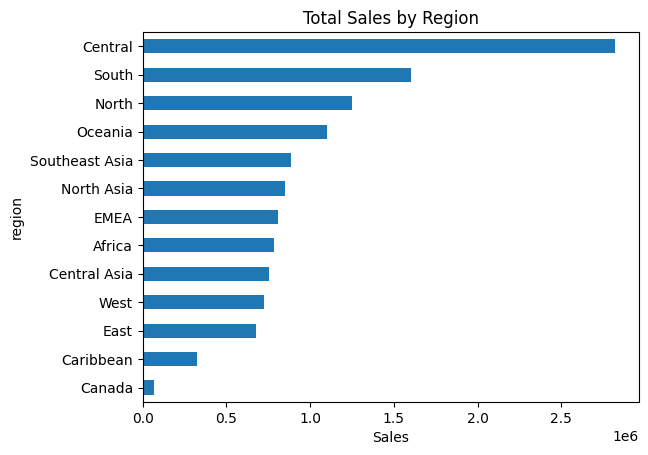

In [3]:
sales_by_region = df.groupby('region')["sales"].sum().sort_values()

sales_by_region.plot(kind='barh')
plt.title('Total Sales by Region')
plt.xlabel('Sales')
plt.show()

## 📦 Analyse 2 — Catégories de produits

Analyse des ventes par catégorie de produit pour identifier les segments les plus performants.

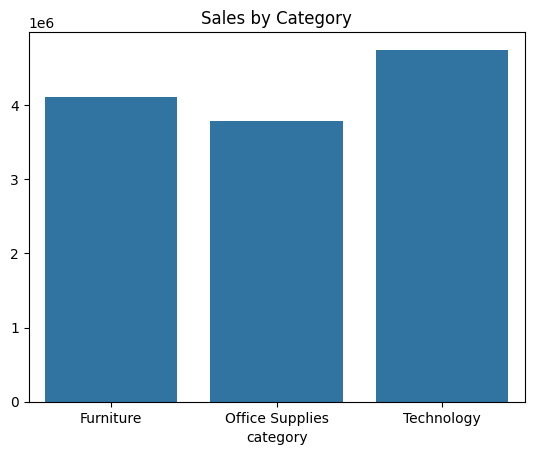

In [4]:
category_sales = df.groupby('category')["sales"].sum()

sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Sales by Category')
plt.show()

## 💸 Analyse 3 — Impact des discounts

Analyse de la relation entre le discount et le profit pour détecter les effets négatifs des remises.

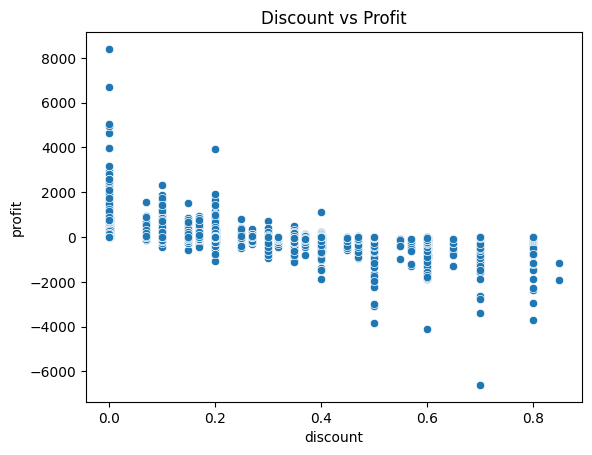

In [5]:
sns.scatterplot(data=df, x='discount', y='profit')
plt.title('Discount vs Profit')
plt.show()

## 📈 Analyse 4 — Profit dans le temps

Visualisation de l’évolution du profit au fil du temps pour détecter des tendances ou des anomalies.

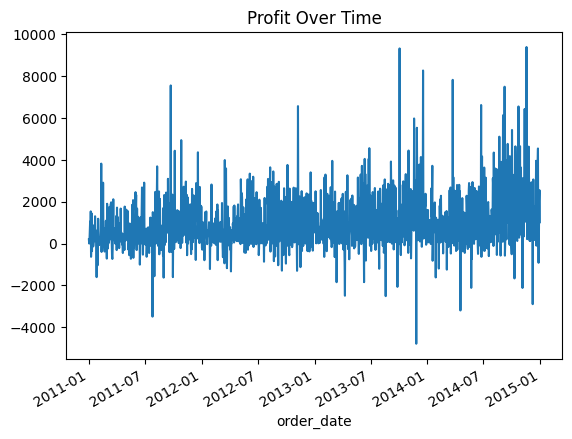

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])

profit_over_time = df.groupby('order_date')['profit'].sum()

profit_over_time.plot()
plt.title('Profit Over Time')
plt.show()

## 👥 Analyse 5 — Segments clients

Analyse de la contribution des différents segments de clients au chiffre d’affaires.

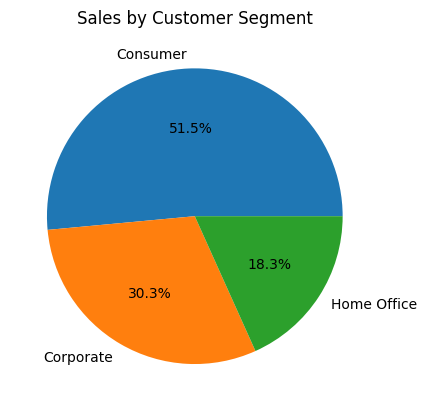

In [7]:
segment_sales = df.groupby('segment')["sales"].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Customer Segment')
plt.ylabel('')
plt.show()

## 🧠 Bonus — Top produits à perte

Liste des 10 produits générant le plus de pertes, à surveiller de près.

In [8]:
top_loss_products = df.groupby('product_name')["profit"].sum().sort_values().head(10)
print(top_loss_products)

product_name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: profit, dtype: float64


## 🔍 Principaux enseignements

- Les remises élevées impactent fortement la rentabilité
- Certains produits génèrent des pertes malgré un volume de ventes important
- Les clients Corporate contribuent significativement au chiffre d'affaires
- La performance commerciale varie fortement selon les régions